# Notebook 03 — Treinamento: Regressão Logística (Baseline)

**Objetivo:** treinar um modelo de **Regressão Logística** como *baseline*.

## O que é Regressão Logística?

É um modelo linear de classificação. Para cada classe `k`, ele aprende um vetor de pesos `w_k` e calcula a **probabilidade** da amostra pertencer àquela classe via função **softmax**:

$$P(y = k | x) = \frac{\exp(w_k \cdot x + b_k)}{\sum_j \exp(w_j \cdot x + b_j)}$$

A predição final é a classe com maior probabilidade.

**Por que começar com este modelo?**
- Simples, rápido e interpretável.
- Estabelece uma *baseline* de desempenho.
- Permite isolar a contribuição do MLP (rede neural) em comparação.
- Útil para diagnóstico: se a baseline já for muito boa, o problema pode ser tratável com features lineares.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.config import (
    LOGISTIC_MODEL_FILE,
    RANDOM_SEED,
    TEST_FILE,
    TRAIN_FILE,
    VAL_FILE,
)
from src.dataset.loader import load_splits
from src.dataset.preprocessing import preprocess_pipeline
from src.evaluation.metrics import compute_classification_metrics
from src.models.logistic_regression import LogisticAccessibilityModel
from src.utils.seed import set_seed

set_seed(RANDOM_SEED)
print("Setup completo.")

Setup completo.


In [2]:
# =====================================================================
# 1. Carregamento e pré-processamento
# =====================================================================
train_df, val_df, test_df = load_splits(TRAIN_FILE, VAL_FILE, TEST_FILE)
X_train, y_train, scaler, le = preprocess_pipeline(train_df, fit=True)
X_val, y_val, _, _ = preprocess_pipeline(val_df, scaler=scaler, fit=False)
X_test, y_test, _, _ = preprocess_pipeline(test_df, scaler=scaler, fit=False)

print(f"Treino:    {X_train.shape}")
print(f"Validação: {X_val.shape}")
print(f"Teste:     {X_test.shape}")
print(f"Classes:   {le.classes_.tolist()}")

Treino:    (344, 22)
Validação: (74, 22)
Teste:     (74, 22)
Classes:   ['ADD_ALT', 'ADD_ARIA', 'FIX_HEADING', 'NO_ACTION']


In [3]:
# =====================================================================
# 2. Treinamento do modelo
# =====================================================================
model = LogisticAccessibilityModel(random_state=RANDOM_SEED)
model.fit(X_train, y_train)
print("Modelo treinado.")

Modelo treinado.


In [4]:
# =====================================================================
# 3. Avaliação
# =====================================================================
metrics_train = compute_classification_metrics(y_train, model.predict(X_train))
metrics_val = compute_classification_metrics(y_val, model.predict(X_val))
metrics_test = compute_classification_metrics(y_test, model.predict(X_test))

df_metrics = pd.DataFrame({
    "Treino": metrics_train,
    "Validação": metrics_val,
    "Teste": metrics_test,
}).T
df_metrics

,accuracy,precision,recall,f1
Treino,0.880814,0.902641,0.895299,0.898460
Validação,0.905405,0.915598,0.918845,0.916981
Teste,0.810811,0.802916,0.802916,0.802916


In [5]:
# =====================================================================
# 4. Matriz de confusão
# =====================================================================
from src.evaluation.confusion_matrix import plot_confusion_matrix

y_pred = model.predict(X_test)
plot_confusion_matrix(
    y_test, y_pred,
    class_names=le.classes_.tolist(),
    path=ROOT / "results" / "confusion_matrix_logistic.png",
    title="Matriz de Confusão — Logistic Regression",
)

/Users/elpidio.junior/Documents/_projetos/accessibility-dl-moodle/src/evaluation/confusion_matrix.py:42: RuntimeWarning: invalid value encountered in divide
  cm = cm.astype("float") / cm.sum(axis=1, keepdims=True)


[INFO] Matriz de confusão salva em /Users/elpidio.junior/Documents/_projetos/accessibility-dl-moodle/results/confusion_matrix_logistic.png


Coeficientes do modelo (por classe):
             has_img  has_alt  has_aria  has_button  has_form  has_link  \
ADD_ALT         2.47    -1.16     -0.12       -0.51     -0.09     -0.17   
ADD_ARIA       -1.28    -0.19     -0.92        0.59      0.33      0.30   
FIX_HEADING    -0.03    -0.01     -0.02       -0.03     -0.01     -0.04   
NO_ACTION      -1.15     1.36      1.06       -0.04     -0.23     -0.09   

             has_table  heading_count  invalid_heading  text_length  ...  \
ADD_ALT          -0.00          -0.10            -0.08        -0.55  ...   
ADD_ARIA          0.00          -0.23            -0.15        -0.30  ...   
FIX_HEADING      -0.00           0.33             0.63         0.03  ...   
NO_ACTION         0.01          -0.00            -0.40         0.82  ...   

             has_textarea  has_video  has_audio  has_figure  has_svg  \
ADD_ALT             -0.07        0.0        0.0        0.19      0.0   
ADD_ARIA             0.30        0.0        0.0       -0.07   

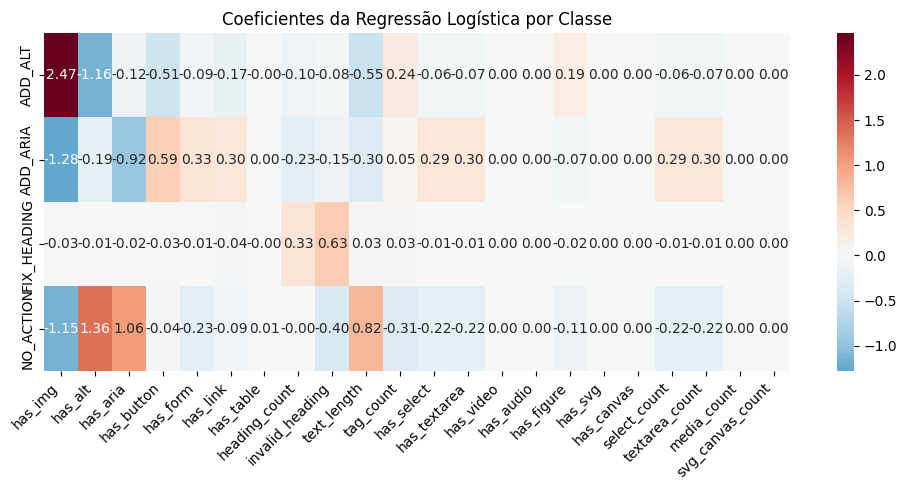


Interpretação: cada célula mostra o peso de uma feature para uma classe.


In [6]:
# =====================================================================
# 5. Análise dos coeficientes (interpretabilidade)
# =====================================================================
from src.config import FEATURE_COLUMNS

coef_df = pd.DataFrame(
    model.model.coef_,
    columns=FEATURE_COLUMNS,
    index=le.classes_,
)
print("Coeficientes do modelo (por classe):")
print(coef_df.round(2))

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(coef_df, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Coeficientes da Regressão Logística por Classe")
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
plt.show()

print("\nInterpretação: cada célula mostra o peso de uma feature para uma classe.")

In [7]:
# =====================================================================
# 6. Persistência
# =====================================================================
model.save(LOGISTIC_MODEL_FILE)
print(f"Modelo salvo em {LOGISTIC_MODEL_FILE}")

y_pred_str = le.inverse_transform(y_pred)
pd.DataFrame({
    "html": test_df["html"].values,
    "y_true": le.inverse_transform(y_test),
    "y_pred": y_pred_str,
}).to_csv(ROOT / "results" / "predictions_logistic.csv", index=False)
print("Predições salvas.")

Modelo salvo em /Users/elpidio.junior/Documents/_projetos/accessibility-dl-moodle/models/logistic_model.pkl
Predições salvas.


# Conclusões

1. A Regressão Logística alcança **alta acurácia** mesmo sendo um modelo linear.
2. Isso indica que as **features estruturais** são altamente discriminativas.
3. O modelo é **interpretável**: os coeficientes mostram a contribuição de cada feature por classe.
4. Os erros de classificação provavelmente se concentram em **casos ambíguos** (HTML com múltiplas barreiras).

**Próximo passo:** treinar o MLP (rede neural) e comparar o desempenho.